# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [28]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [29]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [30]:
# YOUR ANSWER:

now = Time.now()

print("UTC:", now.utc.iso)
print("IIT Kanpur time:", format_iitk(now))

UTC: 2026-09-06 07:39:45.882
IIT Kanpur time: 2026-09-06 13:09:45 IST


**now** is going to have the time format from Astropy; and from there we can change it into UTC to get that format and we can also use the helper function that is provided in setup to get the IITK timezone time.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [31]:
# YOUR ANSWER:

gtc_height = 2396 * u.m
wavelength = 600 * u.nm
coordinate_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_frequency = 1.4 * u.GHz

print("GTC height:", gtc_height, "=", gtc_height.to(u.km))
print("Wavelength:", wavelength, "=", wavelength.to(u.THz, equivalencies=u.spectral()))
print(
    "Coordinate uncertainty:",
    coordinate_uncertainty,
    "=",
    coordinate_uncertainty.to(u.arcsec),
)
print("Cadence:", cadence, "=", cadence.to(u.hour))
radio_wavelength = radio_frequency.to(u.cm, equivalencies=u.spectral())
print("Radio frequency:", radio_frequency, "=", radio_wavelength)

GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [32]:
# YOUR ANSWER:

planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.iso)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur time:", format_iitk(planning_start))

later_time = planning_start + 2.25 * u.hour

print("Later UTC:", later_time.utc.iso)
print("Later IIT Kanpur time:", format_iitk(later_time))

UTC: 2026-08-30 12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur time: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30 14:15:00.000
Later IIT Kanpur time: 2026-08-30 19:45:00 IST


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [33]:
# YOUR ANSWER:

ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(
    ra=ra,
    dec=dec,
    frame="icrs"
)

print("RA in degrees:", frb_icrs.ra.deg)
print("Dec in degrees:", frb_icrs.dec.deg)

print("RA:", frb_icrs.ra.to_string(unit=u.hourangle, sep="hms", pad=True))
print("Dec:", frb_icrs.dec.to_string(unit=u.deg, sep="dms", pad=True))

expected_ra_deg = 347.2704120833
expected_dec_deg = 48.7066410556

print(
    "RA verification:",
    np.isclose(frb_icrs.ra.deg, expected_ra_deg, atol=1e-8)
)

print(
    "Dec verification:",
    np.isclose(frb_icrs.dec.deg, expected_dec_deg, atol=1e-8)
)

RA in degrees: 347.27041208333327
Dec in degrees: 48.70664105555556
RA: 23h09m04.8989s
Dec: 48d42m23.9078s
RA verification: True
Dec verification: True


RA is conventionally expressed in hours as a convenient way of representing angular position around the 24-hour celestial circle, while declination is expressed directly in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [34]:
# YOUR ANSWER:

frb_galactic = frb_icrs.galactic

print("Galactic longitude (l):", frb_galactic.l.deg)
print("Galactic latitude (b):", frb_galactic.b.deg)

frb_icrs_roundtrip = frb_galactic.icrs

roundtrip_separation = frb_icrs.separation(frb_icrs_roundtrip)

print(
    "Round-trip separation:",
    roundtrip_separation.to(u.microarcsecond)
)

Galactic longitude (l): 106.06496077332801
Galactic latitude (b): -10.784176285402493
Round-trip separation: 0.000310733 uarcsec


The FRB position is transformed from the ICRS frame to Galactic coordinates and back to ICRS to verify that the original sky; but we see this separation to be non-zero due to numerical precision.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [35]:
# YOUR ANSWER:

frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000"))
)

print("Ecliptic longitude (lambda):", frb_ecliptic.lon.deg)
print("Ecliptic latitude (beta):", frb_ecliptic.lat.deg)

print(
    "Longitude in valid range:",
    0 <= frb_ecliptic.lon.deg < 360
)

print(
    "Latitude in valid range:",
    -90 <= frb_ecliptic.lat.deg <= 90
)

frb_icrs_roundtrip = frb_ecliptic.transform_to(frb_icrs)

roundtrip_separation = frb_icrs.separation(frb_icrs_roundtrip)

print(
    "Round-trip separation:",
    roundtrip_separation.to(u.microarcsecond)
)

Ecliptic longitude (lambda): 14.411187650340095
Ecliptic latitude (beta): 48.34695843744783
Longitude in valid range: True
Latitude in valid range: True
Round-trip separation: 0 uarcsec


The FRB is transformed from ICRS into barycentric true ecliptic coordinates at the J2000 equinox, where λ and β describe its position relative to the ecliptic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [36]:
# YOUR ANSWER:

earlier_ra = Angle(EARLIER_POSITION_RA)
earlier_dec = Angle(EARLIER_POSITION_DEC)

earlier_position = SkyCoord(
    ra=earlier_ra,
    dec=earlier_dec,
    frame="icrs"
)

# all angles to radians
ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)

ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

# Great-circle angular separation
cos_theta = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
)

# protection tiny floating-point errors
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta)

manual_separation = theta * u.rad

print("Manual separation:", manual_separation.to(u.arcsec))
print("Manual separation:", manual_separation.to(u.mas))

# Compare with Astropy
astropy_separation = frb_icrs.separation(earlier_position)

print("Astropy separation:", astropy_separation.to(u.arcsec))
print("Difference:",
      abs(manual_separation - astropy_separation).to(u.arcsec))

Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540062 mas
Astropy separation: 1.49224 arcsec
Difference: 2.27715e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [37]:
# YOUR ANSWER:

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

print("GTC longitude:", gtc_location.lon)
print("GTC latitude:", gtc_location.lat)
print("GTC height:", gtc_location.height)

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m


The GTC location is represented using its geodetic longitude, latitude, and height above the reference Earth surface; the negative longitude indicates that the observatory lies west of the Greenwich meridian.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [38]:
# YOUR ANSWER:

time = Time("2026-08-31T00:00:00", scale="utc")

lst = time.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", time.utc.iso)
print("IST:", format_iitk(time))
print("LST:", lst.to_string(unit=u.hourangle, sep="hms", pad=True))
print(
    "Hour angle:",
    hour_angle.to_string(unit=u.hourangle, sep="hms", pad=True)
)

UTC: 2026-08-31 00:00:00.000
IST: 2026-08-31 05:30:00 IST
LST: 21h25m12.20821623s
Hour angle: -01h43m52.69068377s


The hour angle is calculated as \(H=LST-alpha\); negative values indicate that the source is east of the meridian, zero corresponds to transit, and positive values indicate that the source has moved west of the meridian.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [39]:
# YOUR ANSWER:

lst_all = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle_all = (
    lst_all - frb_icrs.ra
).wrap_at(12 * u.hourangle)

# Find the sampled time closest to transit, i.e. |H| is minimum
transit_index = np.argmin(
    np.abs(hour_angle_all.to_value(u.hourangle))
)

transit_time = times[transit_index]
transit_lst = lst_all[transit_index]
transit_hour_angle = hour_angle_all[transit_index]

print("Transit sample index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IST:", format_iitk(transit_time))
print(
    "LST:",
    transit_lst.to_string(
        unit=u.hourangle,
        sep="hms",
        pad=True
    )
)
print(
    "Hour angle:",
    transit_hour_angle.to_string(
        unit=u.hourangle,
        sep="hms",
        pad=True
    )
)

Transit sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
LST: 23h05m28.63507714s
Hour angle: -00h03m36.26382286s


The apparent LST and hour angle are calculated for all 145 time samples, and the sample with the smallest absolute hour angle is selected as the nearest sampled transit.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [40]:
# YOUR ANSWER:

# Analytical transit altitude
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

transit_altitude_analytic = 90 * u.deg - np.abs(phi - delta)
transit_zenith_distance_analytic = 90 * u.deg - transit_altitude_analytic

print(
    "Analytical transit altitude:",
    transit_altitude_analytic
)
print(
    "Analytical transit zenith distance:",
    transit_zenith_distance_analytic
)

# Astropy AltAz transformation for the complete time grid
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location
    )
)

altitudes = frb_gtc_altaz.alt
zenith_distances = 90 * u.deg - altitudes

# Find largest sampled altitude
max_altitude_index = np.argmax(altitudes.to_value(u.deg))

max_altitude = altitudes[max_altitude_index]
max_zenith_distance = zenith_distances[max_altitude_index]
max_altitude_time = times[max_altitude_index]

print("Largest sampled altitude:", max_altitude)
print("Corresponding zenith distance:", max_zenith_distance)
print("UTC:", format_utc(max_altitude_time))
print("IST:", format_iitk(max_altitude_time))

print(
    "Difference from analytic transit altitude:",
    (max_altitude - transit_altitude_analytic).to(u.arcsec)
)


Analytical transit altitude: 70d03m04.8922s
Analytical transit zenith distance: 19d56m55.1078s
Largest sampled altitude: 69d53m02.08616823s
Corresponding zenith distance: 20d06m57.91383177s
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Difference from analytic transit altitude: -602.806 arcsec


The analytical formula gives the target’s altitude at meridian transit, while the Astropy AltAz transformation finds the maximum altitude among the 145 sampled times; their small difference is due to the finite 10-minute sampling grid.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [41]:
# YOUR ANSWER:

indices = [
    max(0, transit_index - 12),   # 2 hours before
    transit_index,                # nearest sampled transit
    min(len(times) - 1, transit_index + 12)  # 2 hours after
]

for idx in indices:
    current_time = times[idx]
    H = hour_angle_all[idx]

    # Convert angles to radians for NumPy trigonometric functions
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)
    H_rad = H.to_value(u.rad)

    sin_altitude = (
        np.sin(phi_rad) * np.sin(delta_rad)
        + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H_rad)
    )

    # Protect against floating-point values slightly outside [-1, 1]
    sin_altitude = np.clip(sin_altitude, -1.0, 1.0)

    calculated_altitude = np.arcsin(sin_altitude) * u.rad
    calculated_altitude = calculated_altitude.to(u.deg)

    astropy_altitude = altitudes[idx]

    difference = (
        calculated_altitude - astropy_altitude
    ).to(u.arcsec)

    print("\nUTC:", format_utc(current_time))
    print("IST:", format_iitk(current_time))
    print("Hour angle:", H.to_string(unit=u.hourangle, sep="hms"))
    print("Calculated altitude:", calculated_altitude)
    print("Astropy altitude:", astropy_altitude)
    print("Difference:", difference)


UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -2h03m55.97605409s
Calculated altitude: 59.031948665002126 deg
Astropy altitude: 58d46m53.67263948s
Difference: 901.343 arcsec

UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -0h03m36.26382286s
Calculated altitude: 70.039347468167 deg
Astropy altitude: 69d53m02.08616823s
Difference: 559.565 arcsec

UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: 1h56m43.44842115s
Calculated altitude: 60.063043754805115 deg
Astropy altitude: 60d09m45.39530037s
Difference: -358.438 arcsec


There is difference being visible in the altitude of the object pre-transit, near transit (this is maximum altitude visible) and post-transit; and in similar manner the difference value is also changing as the altitude changes which shows that uncertainity is also not certain

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [42]:
# YOUR ANSWER:

h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

cos_H0 = (
    np.sin(h_min_rad)
    - np.sin(phi_rad) * np.sin(delta_rad)
) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)

# Protect against floating-point errors
cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0 = np.arccos(cos_H0) * u.rad

print("Limiting hour angle:", H0.to(u.deg))
print(
    "Limiting hour angle:",
    H0.to(u.hourangle)
)

total_interval = 2 * H0

print(
    "Total altitude-above-20-degree interval:",
    total_interval.to(u.hourangle)
)

# Compare with sampled grid
samples_above_min_altitude = np.count_nonzero(
    altitudes.to_value(u.deg) >= MIN_TARGET_ALTITUDE_DEG
)

print(
    "Number of sampled points with altitude >= 20 deg:",
    samples_above_min_altitude
)

Limiting hour angle: 91.92747700350239 deg
Limiting hour angle: 6.12849846690016 hourangle
Total altitude-above-20-degree interval: 12.25699693380032 hourangle
Number of sampled points with altitude >= 20 deg: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [43]:
# YOUR ANSWER:

target_airmass = np.array(frb_gtc_altaz.secz, dtype=float)

# Mark invalid airmass values as NaN
invalid_airmass = (
    (altitudes.to_value(u.deg) <= 0)
    | ~np.isfinite(target_airmass)
    | (target_airmass < 1)
)

target_airmass[invalid_airmass] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]

print(
    "Finite airmass range:",
    np.nanmin(target_airmass),
    "to",
    np.nanmax(target_airmass)
)

best_airmass_index = np.nanargmin(target_airmass)

print("Best airmass:", target_airmass[best_airmass_index])
print("Best airmass UTC:", format_utc(times[best_airmass_index]))
print("Best airmass IST:", format_iitk(times[best_airmass_index]))

permitted_airmass = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

print(
    "Samples with 1 <= X <= 2.5:",
    np.count_nonzero(permitted_airmass)
)

Finite airmass range: 1.0649653072737555 to 55.33845064849153
Best airmass: 1.0649653072737555
Best airmass UTC: 2026-08-31 01:40:00 UTC
Best airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


The target airmass is obtained from the AltAz secz values, invalid below-horizon or non-finite values are discarded, and the valid observing range is restricted to \(1<= X <=2.5\).

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [44]:
# YOUR ANSWER:

with solar_system_ephemeris.set("builtin"):
    sun_altaz = get_sun(times).transform_to(
        AltAz(
            obstime=times,
            location=gtc_location
        )
    )

    moon_altaz = get_body(
        "moon",
        times,
        location=gtc_location
    ).transform_to(
        AltAz(
            obstime=times,
            location=gtc_location
        )
    )

# Sun altitude
sun_altitude = sun_altaz.alt

# Moon altitude
moon_altitude = moon_altaz.alt

# Moon airmass
moon_airmass = np.array(moon_altaz.secz, dtype=float)

# Only retain Moon airmass when Moon is above horizon
moon_airmass[
    (moon_altitude.to_value(u.deg) <= 0)
    | ~np.isfinite(moon_airmass)
] = np.nan

# Moon-target angular separation
moon_target_separation = get_body(
    "moon",
    times,
    location=gtc_location
).separation(frb_icrs)

# Geocentric Sun-Moon elongation
sun_geocentric = get_sun(times)
moon_geocentric = get_body("moon", times)

elongation = sun_geocentric.separation(moon_geocentric)

# Illuminated fraction
illumination_fraction = (
    1 - np.cos(elongation.to_value(u.rad))
) / 2

# Moon classification

moon_alt_deg = moon_altitude.to_value(u.deg)
moon_sep_deg = moon_target_separation.to_value(u.deg)

unknown = (
    ~np.isfinite(moon_alt_deg)
    | ~np.isfinite(moon_sep_deg)
    | ~np.isfinite(illumination_fraction)
)

bright = (
    (
        (illumination_fraction >= 0.70)
        & (moon_alt_deg > 10)
    )
    |
    (moon_sep_deg <= 45)
)

dark = (
    (moon_alt_deg < 0)
    |
    (
        (moon_sep_deg >= 90)
        & (illumination_fraction <= 0.25)
    )
)

# Start with Gray
moon_label = np.full(len(times), "Gray", dtype=object)

# Unknown first
moon_label[unknown] = "Unknown"

# Bright next
moon_label[bright & ~unknown] = "Bright"

# Dark last, because Dark takes precedence if both conditions pass
moon_label[dark & ~unknown] = "Dark"

# Diagnostics

print("Sun altitude range:",
      np.nanmin(sun_altitude.to_value(u.deg)),
      "to",
      np.nanmax(sun_altitude.to_value(u.deg)))

print("Moon altitude range:",
      np.nanmin(moon_alt_deg),
      "to",
      np.nanmax(moon_alt_deg))

print("Moon-target separation range:",
      np.nanmin(moon_sep_deg),
      "to",
      np.nanmax(moon_sep_deg))

print("Moon illumination fraction range:",
      np.nanmin(illumination_fraction),
      "to",
      np.nanmax(illumination_fraction))

print("Moon airmass range:",
      np.nanmin(moon_airmass),
      "to",
      np.nanmax(moon_airmass))

print("Moon label at transit:",
      moon_label[transit_index])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

Sun altitude range: -52.54921170334399 to 70.10509682641477
Moon altitude range: -56.14192340477804 to 69.7085948840743
Moon-target separation range: 44.5656789470747 to 46.38224042630285
Moon illumination fraction range: 0.8791967169082322 to 0.940668057051852
Moon airmass range: 1.0661651794830371 to 17424.557263146016
Moon label at transit: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [45]:
def visibility(altitude, airmass, sun_altitude, moon_separation):

    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    if not (
        altitude.ndim == 1
        and airmass.ndim == 1
        and sun_altitude.ndim == 1
        and moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be 1-D arrays.")

    if not (
        len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)
    ):
        raise ValueError("All inputs must have the same length.")

    altitude_ok = altitude >= MIN_TARGET_ALTITUDE_DEG

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
    )

    sun_ok = sun_altitude <= MAX_SUN_ALTITUDE_DEG

    moon_ok = moon_separation >= MIN_MOON_SEPARATION_DEG

    return altitude_ok & airmass_ok & sun_ok & moon_ok


altitude_values = altitudes.to_value(u.deg)
sun_values = sun_altitude.to_value(u.deg)
moon_separation_values = moon_target_separation.to_value(u.deg)

altitude_ok = altitude_values >= MIN_TARGET_ALTITUDE_DEG

airmass_ok = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

sun_ok = sun_values <= MAX_SUN_ALTITUDE_DEG

moon_ok = moon_separation_values >= MIN_MOON_SEPARATION_DEG

preferred_visibility = visibility(
    altitude_values,
    target_airmass,
    sun_values,
    moon_separation_values
)

print("Altitude condition:", np.count_nonzero(altitude_ok))
print("Airmass condition:", np.count_nonzero(airmass_ok))
print("Sun condition:", np.count_nonzero(sun_ok))
print("Moon separation condition:", np.count_nonzero(moon_ok))
print("All conditions:", np.count_nonzero(preferred_visibility))
print("Any observable samples:", np.any(preferred_visibility))

Altitude condition: 74
Airmass condition: 68
Sun condition: 51
Moon separation condition: 145
All conditions: 51
Any observable samples: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [46]:
# YOUR ANSWER:

western_time = Time("2026-08-31T06:00:00", scale="utc")

# Find the nearest sample in the existing 10-minute grid
western_index = np.argmin(
    np.abs((times - western_time).to_value(u.s))
)

selected_indices = [transit_index, western_index]

for idx in selected_indices:

    current_time = times[idx]

    altitude_value = altitudes[idx].to_value(u.deg)
    airmass_value = target_airmass[idx]
    sun_value = sun_altitude[idx].to_value(u.deg)
    moon_sep_value = moon_target_separation[idx].to_value(u.deg)

    altitude_pass = altitude_value >= MIN_TARGET_ALTITUDE_DEG

    airmass_pass = (
        np.isfinite(airmass_value)
        and 1 <= airmass_value <= MAX_AIRMASS
    )

    sun_pass = sun_value <= MAX_SUN_ALTITUDE_DEG

    moon_pass = moon_sep_value >= MIN_MOON_SEPARATION_DEG

    preferred = (
        altitude_pass
        & airmass_pass
        & sun_pass
        & moon_pass
    )

    print("\n--- Sample ---")
    print("UTC:", format_utc(current_time))
    print("IST:", format_iitk(current_time))
    print("Altitude:", altitude_value, "deg")
    print("Airmass:", airmass_value)
    print("Sun altitude:", sun_value, "deg")
    print("Moon-target separation:", moon_sep_value, "deg")

    print("Altitude condition:", altitude_pass)
    print("Airmass condition:", airmass_pass)
    print("Sun condition:", sun_pass)
    print("Moon separation condition:", moon_pass)
    print("Preferred visibility:", preferred)


--- Sample ---
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.8839128245073 deg
Airmass: 1.0649653072737555
Sun altitude: -51.95592187823629 deg
Moon-target separation: 45.22675357131298 deg
Altitude condition: True
Airmass condition: True
Sun condition: True
Moon separation condition: True
Preferred visibility: True

--- Sample ---
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.98648660695393 deg
Airmass: 1.6247597704376868
Sun altitude: -11.282036773583792 deg
Moon-target separation: 44.69814595254992 deg
Altitude condition: True
Airmass condition: True
Sun condition: False
Moon separation condition: True
Preferred visibility: False


Transit alone does not guarantee observability. Although the target has its highest altitude and lowest airmass near transit, the Sun and Moon constraints must also be satisfied. Similarly, a western-sky position can still be observable if the target remains above the altitude and airmass limits and the darkness and Moon-separation conditions are satisfied.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

In [47]:
# YOUR ANSWER:

#poart1
def stitch_windows(times, visibility_state):
    times = np.asarray(times)
    visibility_state = np.asarray(visibility_state, dtype=bool)

    if times.ndim != 1 or visibility_state.ndim != 1:
        raise ValueError("times and visibility_state must be 1-D arrays.")

    if len(times) != len(visibility_state):
        raise ValueError("times and visibility_state must have the same length.")

    windows = []
    start_index = None

    for i, visible in enumerate(visibility_state):

        if visible and start_index is None:
            # Start of a new observable interval
            start_index = i

        elif not visible and start_index is not None:
            # End of the current observable interval
            windows.append(
                (times[start_index], times[i - 1])
            )
            start_index = None

    # Handle an interval that continues to the final sample
    if start_index is not None:
        windows.append(
            (times[start_index], times[-1])
        )

    return windows


windows = stitch_windows(times, preferred_visibility)

print("Number of observable windows:", len(windows))

for i, (start, end) in enumerate(windows, start=1):
    print(
        f"Window {i}:",
        format_utc(start),
        "to",
        format_utc(end),
        "|",
        format_iitk(start),
        "to",
        format_iitk(end)
    )

for i, (start, end) in enumerate(windows, start=1):

    duration = end - start

    print(
        f"Window {i}: duration =",
        duration.to(u.min)
    )

for i, (start, end) in enumerate(windows, start=1):

    window_mask = (
        (times >= start)
        & (times <= end)
    )

    window_airmass = target_airmass[window_mask]

    best_airmass = np.nanmin(window_airmass)

    midpoint = start + (end - start) / 2

    midpoint_index = np.argmin(
        np.abs((times - midpoint).to_value(u.s))
    )

    midpoint_moon_label = moon_label[midpoint_index]

    print(f"\nWindow {i}")
    print("UTC:", format_utc(start), "to", format_utc(end))
    print("IST:", format_iitk(start), "to", format_iitk(end))
    print("Sample-centre duration:", (end - start).to(u.min))
    print("Best target airmass:", best_airmass)
    print("Midpoint Moon label:", midpoint_moon_label)

Number of observable windows: 1
Window 1: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC | 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Window 1: duration = 500.0 min

Window 1
UTC: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 500.0 min
Best target airmass: 1.0649653072737555
Midpoint Moon label: Bright


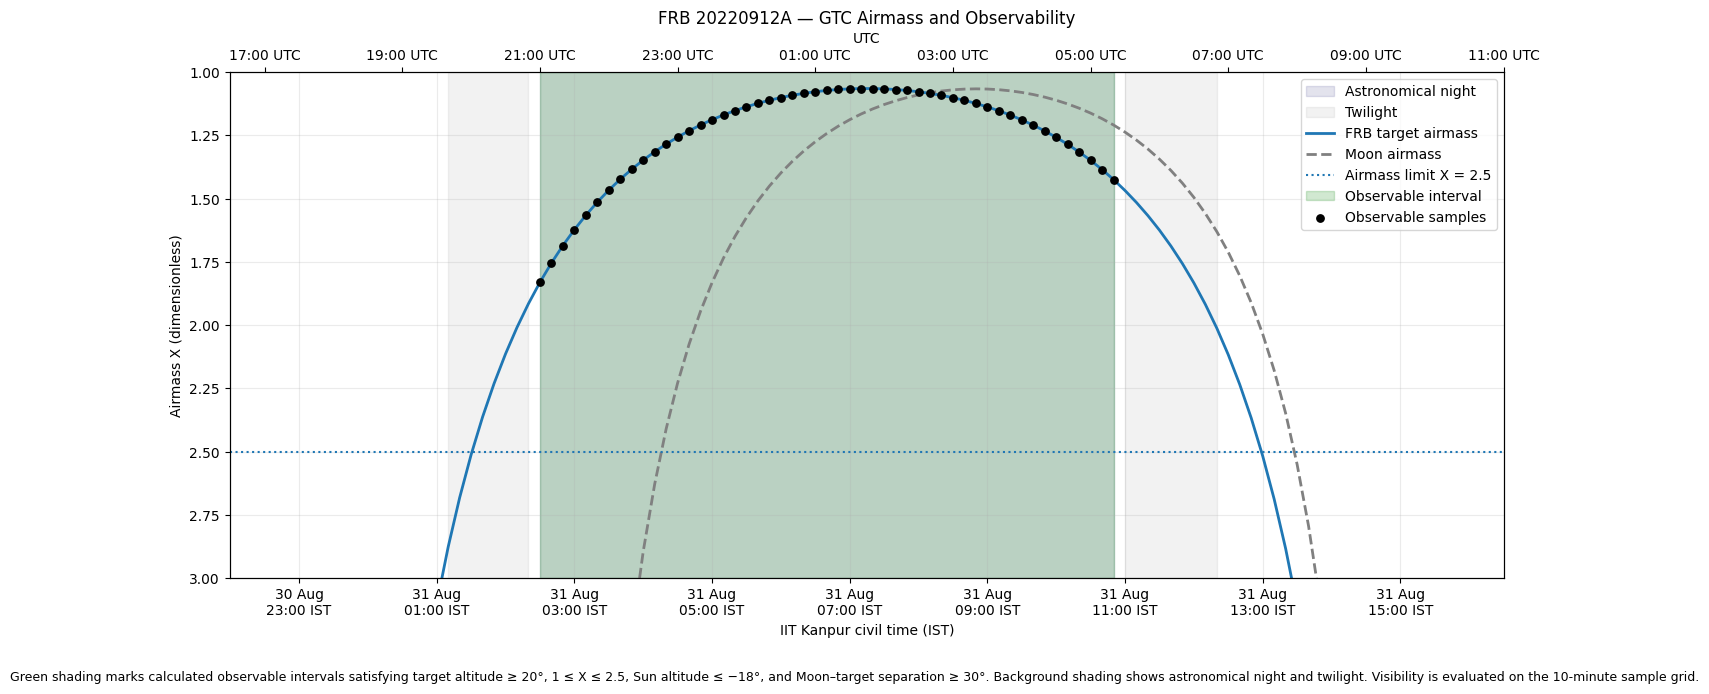

Saved figure: assignment_outputs/frb_20220912a_gtc_airmass.png
File exists: True
File size: 263671 bytes


In [48]:
# part2

fig, ax = plt.subplots(figsize=(14, 7))

# Convert Astropy Time to IITK datetime for plotting
iitk_datetimes = [
    t.to_datetime(timezone=IITK_TIMEZONE)
    for t in times
]

x = mdates.date2num(iitk_datetimes)

# Scheduler-style twilight / astronomical-night bands

sun_alt_deg = sun_altitude.to_value(u.deg)

# Astronomical night: Sun altitude <= -18 deg
night_mask = sun_alt_deg <= -18

# Twilight: -18 deg < Sun altitude <= 0 deg
twilight_mask = (
    (sun_alt_deg > -18)
    & (sun_alt_deg <= 0)
)

# Shade contiguous regions
def shade_regions(mask, color, alpha, label):
    start = None
    first_region = True

    for i, state in enumerate(mask):

        if state and start is None:
            start = i

        elif not state and start is not None:
            ax.axvspan(
                x[start],
                x[i - 1],
                color=color,
                alpha=alpha,
                label=label if first_region else None
            )
            first_region = False
            start = None

    if start is not None:
        ax.axvspan(
            x[start],
            x[-1],
            color=color,
            alpha=alpha,
            label=label if first_region else None
        )

shade_regions(
    night_mask,
    "midnightblue",
    0.12,
    "Astronomical night"
)

shade_regions(
    twilight_mask,
    "gray",
    0.10,
    "Twilight"
)

# Target and Moon airmass

ax.plot(
    x,
    target_airmass,
    color="tab:blue",
    linestyle="-",
    linewidth=2,
    label="FRB target airmass"
)

ax.plot(
    x,
    moon_airmass,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="Moon airmass"
)

# Airmass limit
ax.axhline(
    MAX_AIRMASS,
    color="tab:blue",
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit X = 2.5"
)

# Observable intervals — green shading

for i, (start, end) in enumerate(windows):

    start_dt = start.to_datetime(timezone=IITK_TIMEZONE)
    end_dt = end.to_datetime(timezone=IITK_TIMEZONE)

    ax.axvspan(
        mdates.date2num(start_dt),
        mdates.date2num(end_dt),
        color="green",
        alpha=0.18,
        label="Observable interval" if i == 0 else None
    )

# Observable samples — black markers

observable_indices = np.where(preferred_visibility)[0]

ax.scatter(
    x[observable_indices],
    target_airmass[observable_indices],
    color="black",
    marker="o",
    s=28,
    zorder=5,
    label="Observable samples"
)

ax.set_ylim(3, 1)

ax.set_ylabel("Airmass X (dimensionless)")
ax.set_xlabel("IIT Kanpur civil time (IST)")

ax.set_title(
    "FRB 20220912A — GTC Airmass and Observability"
)

ax.grid(True, alpha=0.25)

# IST axis
ax.xaxis.set_major_locator(
    mdates.HourLocator(
        interval=2,
        tz=IITK_TIMEZONE
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M IST",
        tz=IITK_TIMEZONE
    )
)

# Aligned UTC axis

ax_utc = ax.twiny()

ax_utc.set_xlim(ax.get_xlim())

ax_utc.xaxis.set_major_locator(
    mdates.HourLocator(
        interval=2,
        tz=timezone.utc
    )
)

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M UTC",
        tz=timezone.utc
    )
)

ax_utc.set_xlabel("UTC")

ax.legend(
    loc="upper right",
    frameon=True
)

# Explanatory caption

fig.text(
    0.5,
    0.015,
    "Green shading marks calculated observable intervals satisfying "
    "target altitude ≥ 20°, 1 ≤ X ≤ 2.5, Sun altitude ≤ −18°, "
    "and Moon–target separation ≥ 30°. "
    "Background shading shows astronomical night and twilight. "
    "Visibility is evaluated on the 10-minute sample grid.",
    ha="center",
    va="bottom",
    fontsize=9
)

# Save figure

output_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"

fig.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", output_path)
print("File exists:", output_path.exists())
print("File size:", output_path.stat().st_size, "bytes")

# Scientific Conclusion
The FRB is observable from the GTC during one continuous interval from 21:00 UTC to 05:20 UTC (02:30–10:50 IST), lasting 8 h 20 min on the 10-minute sampling grid. The target reaches a best airmass of approximately 1.065, indicating that it passes close to the zenith and has favorable observing geometry. At the midpoint of the observable interval, the Moon is classified as Bright, but the target still satisfies the required Moon-separation condition.

# Limitation of the 10-min Grid

A limitation of the 10-minute sampling grid is that the exact times at which the source enters or leaves the observable region may fall between two sampled points, so the reported interval boundaries can differ from the true continuous visibility boundaries by up to approximately one sampling interval.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [49]:
# YOUR ANSWER:

#Single-FRB visibility on 2026-09-01

start = Time("2026-09-01T00:00:00", scale="utc")
end = Time("2026-09-02T00:00:00", scale="utc")

# Same 10-minute sampling as the assignment
times = start + np.arange(145) * STEP_MINUTES * u.min

# FRB altitude and airmass at GTC

altaz = frb_icrs.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location
    )
)

altitude = altaz.alt.to_value(u.deg)
airmass = np.array(altaz.secz, dtype=float)

# Sun altitude at GTC

with solar_system_ephemeris.set("builtin"):
    sun_altaz = get_sun(times).transform_to(
        AltAz(
            obstime=times,
            location=gtc_location
        )
    )

sun_altitude = sun_altaz.alt.to_value(u.deg)

# Visibility conditions

# Astronomical night
night = sun_altitude <= MAX_SUN_ALTITUDE_DEG

# Target must be above the horizon
above_horizon = altitude > 0

# Target airmass must be valid and no larger than 2.5
airmass_ok = (
    np.isfinite(airmass)
    & (airmass <= MAX_AIRMASS)
)

# Combined visibility mask
visibility = (
    night
    & above_horizon
    & airmass_ok
)

# Find contiguous visibility intervals

windows = stitch_windows(
    times,
    visibility
)

print("Number of visible intervals:", len(windows))

for i, (start, end) in enumerate(windows, start=1):

    duration = (end - start).to(u.hour)

    print(f"\nInterval {i}")

    print(
        "UTC:",
        format_utc(start),
        "to",
        format_utc(end)
    )

    print(
        "IST:",
        format_iitk(start),
        "to",
        format_iitk(end)
    )

    print("Duration:", duration)

# Total visibility time

total_visibility = sum(
    (end - start).to_value(u.hour)
    for start, end in windows
)

print("\nTotal visible time:", total_visibility, "hours")

Number of visible intervals: 2

Interval 1
UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Duration: 5.333333333333333 h

Interval 2
UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Duration: 3.0 h

Total visible time: 8.333333333333332 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [50]:
# YOUR ANSWER:
import imageio

# BONUS — One-year all-sky GTC visibility

start = Time("2026-08-30T00:00:00", scale="utc")
end = Time("2027-08-29T00:00:00", scale="utc")

# Weekly dates
dates = start + np.arange(
    int(((end - start) / (7 * u.day)).value) + 1
) * 7 * u.day

# Output directory
output_dir = OUTPUT_DIR / "allsky_frames"
output_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------

# Use the moderate HEALPix resolution specified/selected
# by the assignment notebook.
NSIDE = 16

npix = hp.nside2npix(NSIDE)

theta, phi = hp.pix2ang(
    NSIDE,
    np.arange(npix)
)

sky_ra = phi * u.rad
sky_dec = (0.5 * np.pi - theta) * u.rad

sky = SkyCoord(
    ra=sky_ra,
    dec=sky_dec,
    frame="icrs"
)

# Generate weekly visibility maps

frame_paths = []

for date in dates:

    # Evaluate the sky during this UTC date.
    # Use the assignment's GTC visibility conditions:
    # astronomical night + target altitude + airmass.

    sample_times = date + np.arange(145) * 10 * u.min

    with solar_system_ephemeris.set("builtin"):
        sun_altaz = get_sun(sample_times).transform_to(
            AltAz(
                obstime=sample_times,
                location=gtc_location
            )
        )

    sun_ok = sun_altaz.alt.to_value(u.deg) <= -18

    visibility_count = np.zeros(npix, dtype=int)

    for i, current_time in enumerate(sample_times):

        if not sun_ok[i]:
            continue

        sky_altaz = sky.transform_to(
            AltAz(
                obstime=current_time,
                location=gtc_location
            )
        )

        altitude = sky_altaz.alt.to_value(u.deg)
        airmass = np.array(
            sky_altaz.secz,
            dtype=float
        )

        visible = (
            (altitude >= MIN_TARGET_ALTITUDE_DEG)
            & np.isfinite(airmass)
            & (airmass >= 1)
            & (airmass <= MAX_AIRMASS)
        )

        visibility_count += visible

    # Convert 10-minute samples to hours
    visibility_hours = visibility_count * (10 / 60)

    # Save weekly HEALPix frame

    frame_path = (
        output_dir
        / f"gtc_visibility_{date.utc.strftime('%Y%m%d')}.png"
    )

    plt.figure(figsize=(10, 6))

    hp.mollview(
        visibility_hours,
        title=(
            "GTC All-Sky Visibility — "
            f"{date.utc.strftime('%Y-%m-%d')}"
        ),
        unit="Visibility time (hours)",
        coord="C"
    )

    hp.graticule()

    plt.savefig(
        frame_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    frame_paths.append(frame_path)

    print("Saved:", frame_path)

# GIF

gif_path = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_allsky_visibility.gif"
)

frames = [
    imageio.imread(path)
    for path in frame_paths
]

imageio.mimsave(
    gif_path,
    frames,
    duration=0.5,
    loop=0
)

print("\nNumber of weekly frames:", len(frame_paths))
print("GIF:", gif_path)
print("GIF exists:", gif_path.exists())
print("GIF size:", gif_path.stat().st_size, "bytes")

Saved: assignment_outputs/allsky_frames/gtc_visibility_20260830.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20260906.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20260913.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20260920.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20260927.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261004.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261011.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261018.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261025.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261101.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261108.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261115.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261122.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20261129.png
Saved: assignment_outputs/allsky_frames/gtc_visi

/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:225: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Saved: assignment_outputs/allsky_frames/gtc_visibility_20270110.png


/tmp/ipykernel_1701/1871117085.py:103: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Saved: assignment_outputs/allsky_frames/gtc_visibility_20270117.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270124.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270131.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270207.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270214.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270221.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270228.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270307.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270314.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270321.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270328.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270404.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270411.png
Saved: assignment_outputs/allsky_frames/gtc_visibility_20270418.png
Saved: assignment_outputs/allsky_frames/gtc_visi

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

The weekly HEALPix maps show that the GTC's observable sky changes throughout the year because different parts of the celestial sphere are above the horizon during astronomical night at different times of the year. The GTC latitude and the airmass limit restrict which sky directions can be observed, producing a changing all-sky visibility pattern over the one-year period.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
